05. 반파정류회로와 전파정류회로



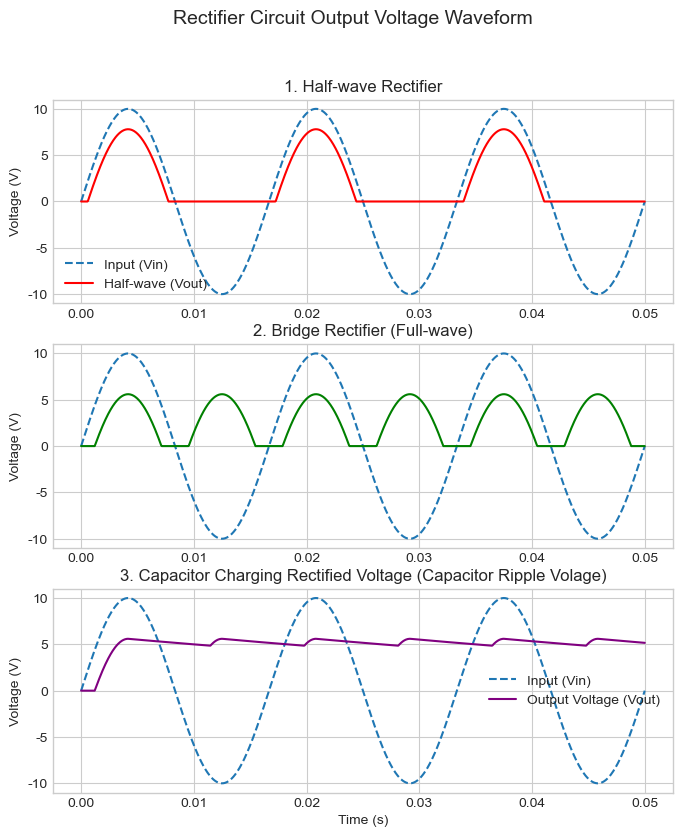



--- 파형 계산값 (이론값 계산) ---
1. 반파정류 회로 실험 결과
  - Vout Peak (Vp): 7.80 V
  - Vout Average (V_avg): 2.48 V

2. 전파정류 회로 실험 결과
  - Vout Peak (Vp): 5.60 V
  - Vout Average (V_avg): 3.57 V

 3. 커패시터 충전 리플 전압 실험 결과
  - Ripple Voltage (V_ripple): 0.92 V
  - DC Output Voltage (V_dc): 5.14 V


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
from scipy.optimize import curve_fit
import pandas as pd

print("05. 반파정류회로와 전파정류회로")
print()

# 입력 데이터 :  실험에 사용한 파라미터 
Vin_peak = 10  # 입력 전압 최대값 (Vpp=20V) / 0전압부터 양의 전압 peak 값은 10V
frequency = 60 # 주파수 (Hz)
R = 510        # 부하저항 (Ohm)
C = 100e-6     # 커패시터 용량 (F)  100uF
V_f = 2.2      # LED 순방향 전압 강하 (V) / 1N4007 Si Diode를 사용한 경우 0.7V

# 입력 AC 전압 파형 설정
t = np.linspace(0, 3 / frequency, 1000)
vin = Vin_peak * np.sin(2 * np.pi * frequency * t)

# 반파 정류회로 설정
vout_half = np.maximum(0, vin - V_f)
Vp_half = Vin_peak - V_f
Vavg_half = Vp_half / np.pi

# 전파 정류회로 설정,  전파 정류(Bridge Diode 적용) 시 2개의 다이오드 전압 강하 (2 * V_f)
vout_bridge = np.maximum(0, np.abs(vin) - 2 * V_f)
Vp_bridge = Vin_peak - (2 * V_f)
Vavg_bridge = (2 * Vp_bridge) / np.pi

# 커패시터 평활회로
vout_smoothing = np.zeros_like(t)
for i in range(1, len(t)):
    # 충전 과정
    if np.abs(vin[i]) - (2 * V_f) > vout_smoothing[i-1]:
        vout_smoothing[i] = np.abs(vin[i]) - (2 * V_f)
    # 방전 과정
    else:
        time_constant = R * C
        dt = t[i] - t[i-1]
        vout_smoothing[i] = vout_smoothing[i-1] * np.exp(-dt / time_constant)
V_ripple = Vp_bridge / (2 * frequency * R * C)
Vout_dc_smoothing = Vp_bridge - (V_ripple / 2)

# 실험 결과 그래프 그리기 / 폰트 설정
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(3, 1, figsize=(8, 9))
fig.suptitle('Rectifier Circuit Output Voltage Waveform', fontsize=14)

axs[0].plot(t, vin, label='Input (Vin)', linestyle='--')
axs[0].plot(t, vout_half, label='Half-wave (Vout)', color='red')
axs[0].set_title('1. Half-wave Rectifier')
axs[0].set_ylabel('Voltage (V)')
axs[0].legend()

axs[1].plot(t, vin, label='Input (Vin)', linestyle='--')
axs[1].plot(t, vout_bridge, label='Bridge (Vout)', color='green')
axs[1].set_title('2. Bridge Rectifier (Full-wave)')
axs[1].set_ylabel('Voltage (V)')
axs[1].legend

axs[2].plot(t, vin, label='Input (Vin)', linestyle='--')
axs[2].plot(t, vout_smoothing, label='Output Voltage (Vout)', color='purple')
axs[2].set_title('3. Capacitor Charging Rectified Voltage (Capacitor Ripple Volage)')
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('Voltage (V)')
axs[2].legend()

plt.show()

# 계산값 출력기기
print()
print("\n--- 파형 계산값 (이론값 계산) ---")
print(f"1. 반파정류 회로 실험 결과")
print(f"  - Vout Peak (Vp): {Vp_half:.2f} V")
print(f"  - Vout Average (V_avg): {Vavg_half:.2f} V")

print()
print(f"2. 전파정류 회로 실험 결과")
print(f"  - Vout Peak (Vp): {Vp_bridge:.2f} V")
print(f"  - Vout Average (V_avg): {Vavg_bridge:.2f} V")

print()
print(f" 3. 커패시터 충전 리플 전압 실험 결과")
print(f"  - Ripple Voltage (V_ripple): {V_ripple:.2f} V")
print(f"  - DC Output Voltage (V_dc): {Vdc_smooth:.2f} V")